In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load data and merge
train_trans = pd.read_csv('../../data/raw/train_transaction.csv')
train_id = pd.read_csv('../../data/raw/train_identity.csv')

train = train_trans.merge(train_id, on='TransactionID', how='left')
train.shape

2691793800


In [11]:
print(train.shape)
print(f"{train.memory_usage(deep=True).sum() / 1024**2}MBs")
print(train.dtypes.value_counts())
print(train.isnull().sum())

(590540, 434)
2567.094612121582MBs
float64    399
object      31
int64        4
Name: count, dtype: int64
TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


Total transactions: 590540
Transactions flagged as fraud: 20663
Legitimate transactions: 569877
Percentage of transactions that are fraudulent: 3.50%


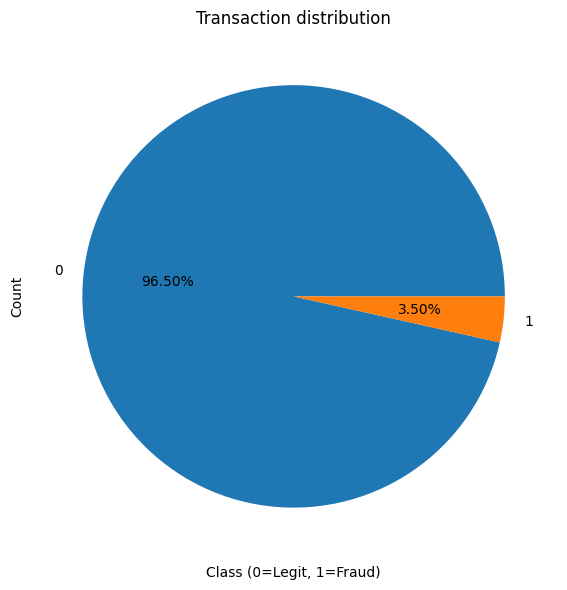

In [22]:
# Analyse Fraud Distribution
fraud_count = train['isFraud'].sum()
total_count = len(train)
legitimate = total_count - fraud_count
fraud_rate = (fraud_count / total_count) * 100

print(f"Total transactions: {total_count}")
print(f"Transactions flagged as fraud: {fraud_count}")
print(f"Legitimate transactions: {legitimate}")
print(f"Percentage of transactions that are fraudulent: {fraud_rate:.2f}%")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
train['isFraud'].value_counts().plot(kind='pie', autopct='%1.2f%%')
ax.set_title('Transaction distribution')
ax.set_xlabel('Class (0=Legit, 1=Fraud)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()